<a href="https://colab.research.google.com/github/pmcray/worldmaker/blob/master/traveller_world_generator.ipynb" target="_parent"><img
src="https://colab.research.google.com/assets/colab-badge.svg"
alt="Open In Colab"/></a>

# Traveller Sector Generator

Generates a whole sector and renders it in the style of the Classic Traveller
maps, using the `worldmaker` package.

This notebook is a thin front-end over the tested package; the rules are not
duplicated here.


In [1]:
# --- Colab bootstrap -------------------------------------------------
# On Google Colab this installs worldmaker from GitHub. Run from a clone
# of the repository it finds the local package instead and does nothing.
# Either way it is safe to re-run.
WORLDMAKER_REF = "master"     # branch, tag or commit to install on Colab

import os
import subprocess
import sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q",
         f"git+https://github.com/pmcray/worldmaker.git@{WORLDMAKER_REF}"],
        check=True)
    # Canon fetched from travellermap.com is cached beside the notebook
    # rather than inside site-packages.
    os.environ.setdefault("WORLDMAKER_CANON_CACHE", "/content/canon_cache")

try:
    import worldmaker as wm
except ModuleNotFoundError:
    raise ModuleNotFoundError(
        "worldmaker not found. Start Jupyter from the root of a clone of "
        "the repository, or install it with\n"
        "    pip install git+https://github.com/pmcray/worldmaker.git") from None

print("worldmaker", wm.__version__, "ready" + (" on Colab" if IN_COLAB else ""))

worldmaker 0.1.0 ready


In [2]:
import random

import worldmaker as wm

random.seed(1105)

# A full sector is 32x40 hexes: sixteen 8x10 subsectors, generated in one pass
# so polities, routes and names are coherent across the whole map.
sector = wm.generate_full_sector("Foreven Reach")
print(f"{len(sector.systems)} systems in {sector.width}x{sector.height} hexes")
print(f"{len(sector.polities)} polities, "
      f"{sum(1 for r in sector.routes if r[2] == 'xboat')} Xboat links")

650 systems in 32x40 hexes
5 polities, 0 Xboat links


## Polities

In [3]:
for p in sector.polities:
    print(f"{p.allegiance_code}  {p.name:34s} capital {p.capital_hex}  "
          f"{len(p.controlled_systems):3d} worlds  DI {p.defense_index:2d}  "
          f"{p.polity_type}")

unaligned = sum(1 for s in sector.systems.values() if s.allegiance == "Na")
print(f"\n{unaligned} independent systems")

Ha  Halcyon Protectorate               capital 1210   86 worlds  DI 12  Major Race Polity
Vi  Vilis Directorate                  capital 1431   32 worlds  DI 12  Interstellar Empire
Py  Pyrrhus Protectorate               capital 0206   34 worlds  DI 10  Major Race Polity
Xa  Xanthe Protectorate                capital 1101   17 worlds  DI 10  Major Race Polity
Si  Sindal Protectorate                capital 0725   46 worlds  DI 10  Interstellar Empire

435 independent systems


## Subsectors

In [4]:
for letter, name in sorted(sector.subsector_names.items()):
    idx = ord(letter) - 65
    col0, row0 = (idx % 4) * 8, (idx // 4) * 10
    count = sum(
        1 for h in sector.systems
        if col0 < int(h[:2]) <= col0 + 8 and row0 < int(h[2:]) <= row0 + 10)
    print(f"{letter}  {name:16s} {count:3d} systems")

A  Lanus             35 systems
B  Deniave           46 systems
C  Kelaloth          36 systems
D  Fenenus           38 systems
E  Moreus            33 systems
F  Vereria           45 systems
G  Ulel              42 systems
H  Vanerim           41 systems
I  Fenaren           40 systems
J  Ruaoth            42 systems
K  Orriyr            38 systems
L  Vereel            46 systems
M  Falinesh          42 systems
N  Zorien            46 systems
O  Fenanave          40 systems
P  Renoan            40 systems


## Sector map\n\nThe full foldout, in the classic black-ink style.

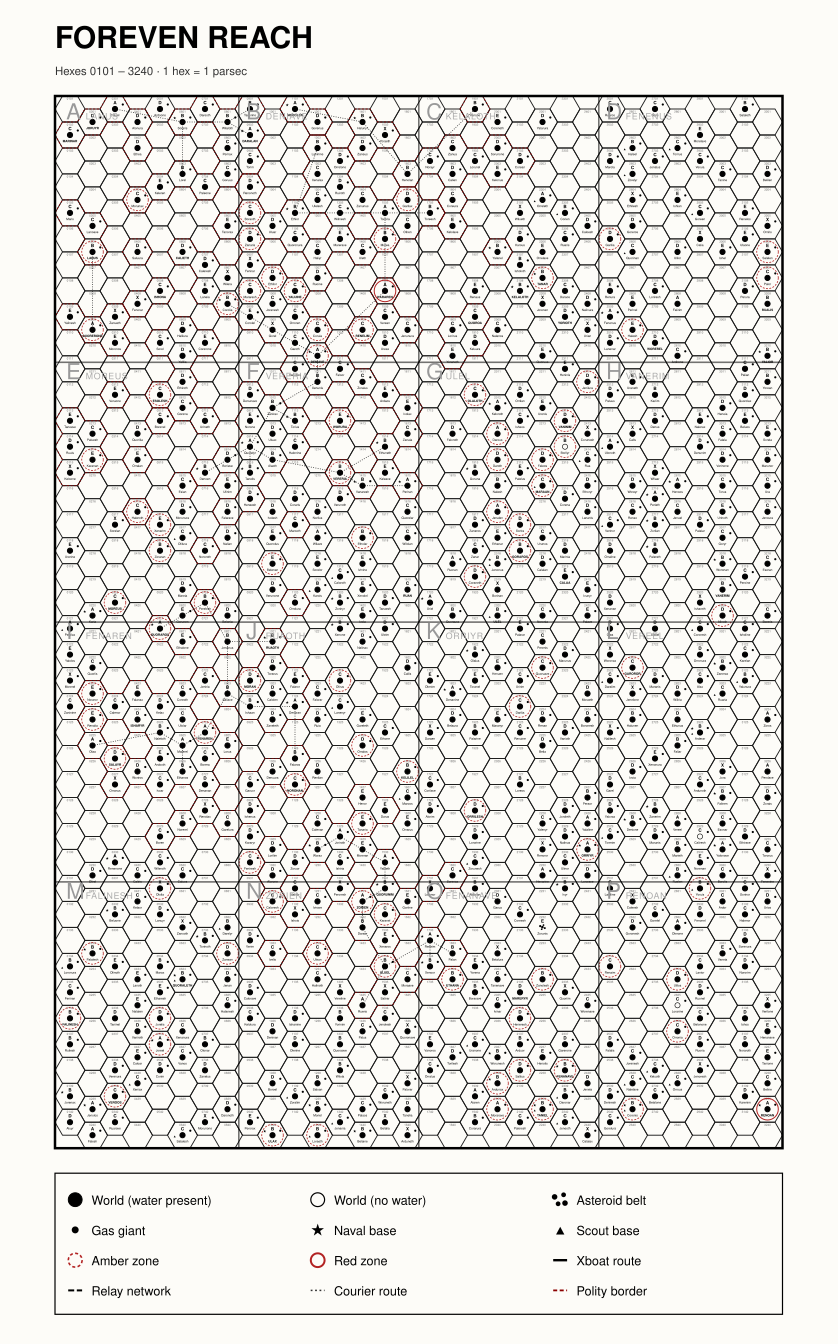

In [5]:
from IPython.display import SVG, display

display(SVG(wm.generate_sector_svg(sector)))

## Subsector map\n\nA single subsector at Supplement-page scale.

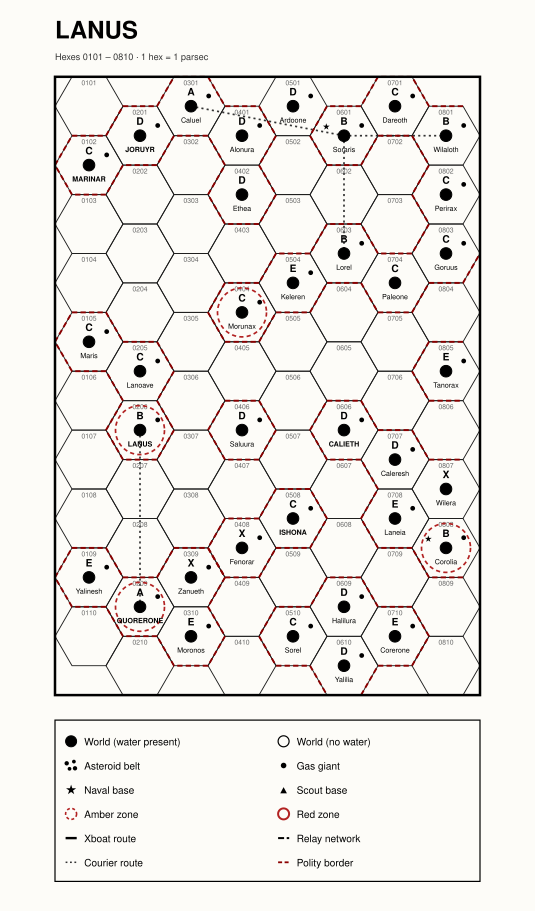

In [6]:
display(SVG(wm.generate_subsector_svg(sector, sector.subsector_names.get('A', 'Subsector A'))))

### Any other subsector

Pass the origin hex of the subsector window: subsector F starts at 0911.

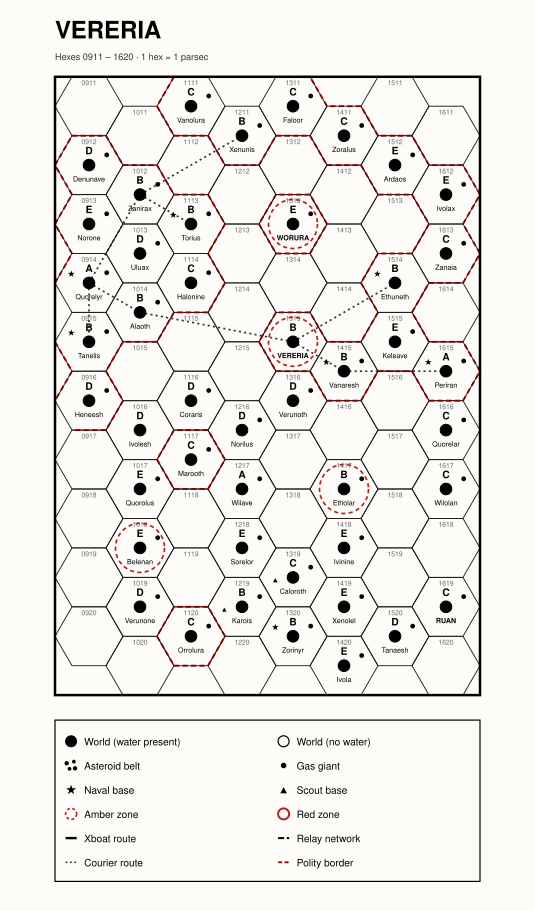

In [7]:
display(SVG(wm.generate_subsector_svg(
    sector, sector.subsector_names.get('F', 'Subsector F'),
    origin_col=9, origin_row=11)))

## Building a sector from a universe

The *Sector Construction Guide* opens by asking a handful of questions
before any dice are rolled (pp.3-8): what the theme is, how densely the
stars are packed, how advanced the setting is, whether it is growing or
falling, and whether any anomaly bends the rules over part of the map.
`create_universe()` takes those answers and drives generation from them.

In [8]:
universe = wm.create_universe("Foreven Reach", preset="frontier")

# A "Bermuda Triangle" where colonies fail, and a rift that thins the stars
universe.add_anomaly("barren", "The Quiet Zone", centre="1124", radius=2)
universe.add_anomaly("rift", "The Gap", centre="0505", radius=2)

wm.build_default_timeline(universe)
print(universe.describe())

# Foreven Reach

**Theme**: Expansion and conflict along a contested frontier
**Star density**: scattered (system on 1D 5+)
**Maximum Tech Level**: 11 (developing)
**Trajectory**: expansion (population DM +1)
**Native sophonts**: standard
**Interstellar polities**: 2
**Current year**: 1105

## Background
Newly opened space. Settlement waves are still moving outward and few worlds have been charted twice.

## Anomalies
- **The Quiet Zone** (19 hexes): Failed colonies and lost ships; the worlds stand empty
- **The Gap** (19 hexes): An interstellar rift: few or no systems

## Timeline
- -298895: Ancient civilisation active in the region; sophonts transplanted between worlds
- 305: First interstellar arrivals in the region
- 705: Widespread settlement begins
- 905: The current wave of expansion begins
- 1055: The Quiet Zone: the last colony attempt fails
- 1065: Frontier surveys reach the far side of the region


In [9]:
random.seed(1105)
themed = wm.generate_universe_sector(universe, "Foreven Reach")
print(f"{len(themed.systems)} systems, {len(themed.polities)} polities")

# The rift is empty, and the Quiet Zone's worlds stand abandoned
rift = universe.anomalies[1].hexes
print(f"systems inside the rift: {sum(1 for h in rift if h in themed.systems)}")

for hex_coord in universe.anomalies[0].hexes:
    system = themed.systems.get(hex_coord)
    if system and system.mainworld:
        print(f"  {hex_coord}  {system.mainworld.uwp}  "
              f"{' '.join(system.mainworld.trade_codes)}")

399 systems, 2 polities
systems inside the rift: 0
  0924  X796000-0  Lt Ba
  0925  X655000-0  Ga Ba
  1022  X989000-0  Lt Ni Ba
  1025  X979000-0  Ba
  1224  X377000-0  Ba


## Sector data file

Traveller5 Second Survey data, in the column-delimited format
travellermap.com defines. The separator line fixes each field's width, so
every value sits in its own column: Hex, Name, UWP, Remarks, then the
importance, economic and cultural extensions, nobility, bases, travel
zone, PBG, world count, allegiance and stellar data.

In [10]:
sec_data = wm.export_sector_sec_file(sector)
print("\n".join(sec_data.splitlines()[:25]))
print("...")

# Foreven Reach
# Traveller5 Second Survey, column delimited
# Subsector A: Lanus
# Subsector B: Deniave
# Subsector C: Kelaloth
# Subsector D: Fenenus
# Subsector E: Moreus
# Subsector F: Vereria
# Subsector G: Ulel
# Subsector H: Vanerim
# Subsector I: Fenaren
# Subsector J: Ruaoth
# Subsector K: Orriyr
# Subsector L: Vereel
# Subsector M: Falinesh
# Subsector N: Zorien
# Subsector O: Fenanave
# Subsector P: Renoan
#
Hex  Name        UWP       Remarks          {Ix}   (Ex)    [Cx]   N     B   Z PBG W  A  Stellar
---- ----------- --------- ---------------- ------ ------- ------ ----- --- - --- -- -- ------------------------
0102 Marinar     C888A86-7 Hi               { 0 }  (A99+2) [6C88] B           501 25 Py K8 V K3 V
0105 Maris       C598120-4 Lo Lt            { -2 } (A00+1) [915B] B     M     523 39 Py G0 V
0109 Yalinesh    EA88545-3 Ag Lt Ni         { -3 } (E42+4) [6777] B           403 31 Py K7 V
0113 Taneave     E869422-3 Lt Ni            { -3 } (330+5) [85D9] B           401 18

In [11]:
# Write the maps and data to disk
with open("sector_map.svg", "w") as f:
    f.write(wm.generate_sector_svg(sector))
with open("sector.sec", "w") as f:
    f.write(sec_data)
print("written: sector_map.svg, sector.sec")

written: sector_map.svg, sector.sec


In [12]:
# On Colab, take the map and the sector data away with you before the
# runtime is recycled.
import sys
from pathlib import Path

written = ["sector_map.svg", "sector.sec"]

if "google.colab" in sys.modules:
    from google.colab import files
    for name in written:
        files.download(name)
else:
    for name in written:
        print(Path(name).resolve())

/home/user/worldmaker/sector_map.svg
/home/user/worldmaker/sector.sec
